<div style="border: solid blue 2px; padding: 15px; margin: 10px">
  <b>Overall Summary of the Project – Iteration 2</b><br><br>

  Hi Forestall, I’m <b>Victor Camargo</b> (<a href="https://hub.tripleten.com/u/e9cc9c11" target="_blank">TripleTen Hub profile</a>). I reviewed your updates, and you did a great job addressing the previous feedback.<br><br>

  <b>Nice work on:</b><br>
  ✔️ Providing a clear project overview and describing the dataset<br>
  ✔️ Performing the correct 60/20/20 split into train, validation, and test sets<br>
  ✔️ Selecting Random Forest as the best-performing model and tuning key hyperparameters<br>
  ✔️ Running a sanity check with a baseline model and feature importance analysis<br><br>

  This project is approved ✅ — great job, Forestall!<br><br>

  <b>Please ensure</b> that all cells run smoothly from top to bottom and display their outputs before submitting — this helps keep your analysis easy to follow.  
  <b>Kind reminder:</b> try not to move, change, or delete reviewer comments, as they are there to track progress and provide better support during your revisions.<br><br>
</div>


<div style="border: solid blue 2px; padding: 15px; margin: 10px">
  <b>Overall Summary of the Project – Iteration 1</b><br><br>

  Hi Forestall, I’m <b>Victor Camargo</b> (<a href="https://hub.tripleten.com/u/e9cc9c11" target="_blank">TripleTen Hub profile</a>). I’ll be reviewing your project and sharing feedback using the color-coded comments below. Thanks for submitting your work!<br><br>

  <b>Nice work on:</b><br>
  ✔️ Providing a clear project overview and describing the dataset<br>
  ✔️ Performing the correct 60/20/20 split into train, validation, and test sets<br>
  ✔️ Selecting Random Forest as the best-performing model and tuning key hyperparameters<br>
  ✔️ Running a sanity check with a baseline model and feature importance analysis<br><br>

  A few things still need your attention before approval:<br>
  🔴 In the model comparison step, the validation accuracies are currently hardcoded. You need to actually train and evaluate Logistic Regression, Decision Tree, and Random Forest on the training/validation sets and report the real results.<br><br>

  <hr>

  🔹 <b>Legend:</b><br>
  🟢 Green = well done<br>
  🟡 Yellow = suggestions<br>
  🔴 Red = must fix<br>
  🔵 Blue = your comments or questions<br><br>
  
  <b>Please ensure</b> that all cells run smoothly from top to bottom and display their outputs before submitting — this helps keep your analysis easy to follow.  
  <b>Kind reminder:</b> try not to move, change, or delete reviewer comments, as they are there to track progress and provide better support during your revisions.<br><br>
</div>


# Project Overview 
- This project aims to develop a machine learning model for Megaline
- The goal is to build a model that accurately recommends the most suitable plan for each subscriber
-----

# The dataset includes: 
- Number of calls
- Total call duration(minutes)
- Number of text messages
- Internet mb usages
- Current plan(is_ultra: 1 for Ultra, and 0 for Smart)
-----

# Project Procedures 
- Splitting the data into training, validation, and test sets
- Evaluating multiple models(Logistic Regression, Decision Tree, Random Forest)
- Tuning hyperparameters to optimize performance
- Conducting a final test evaluation to ensure generalization
- Perform a sanity check to validate model logic and reliability 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Loading dataset
df = pd.read_csv("users_behavior.csv")

features = df.drop(columns=['is_ultra'])
target = df['is_ultra']

In [6]:
# Describing the data
df.head()  
df.head(10) 

df.shape
df.info()

df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


,calls,minutes,messages,mb_used,is_ultra
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,63.038892,438.208787,38.281269,17207.673836,0.306472
std,33.236368,234.569872,36.148326,7570.968246,0.461100
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,274.575000,9.000000,12491.902500,0.000000
50%,62.000000,430.600000,30.000000,16943.235000,0.000000
75%,82.000000,571.927500,57.000000,21424.700000,1.000000
max,244.000000,1632.060000,224.000000,49745.730000,1.000000


<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Nice start! You clearly outlined the project goals, dataset description, and main steps of the workflow. Your initial dataset inspection with <code>head()</code>, <code>shape</code>, <code>info()</code>, and <code>describe()</code> is thorough and shows good practice for understanding the structure before modeling.
</div>


In [7]:
# First split: test set (20%)
features_temp, features_test, target_temp, target_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Second split: divide remaining data into training (60%) and validation (20%)
features_train, features_valid, target_train, target_valid = train_test_split(
    features_temp, target_temp, test_size=0.25, random_state=42  
) 

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Great job splitting the dataset into training, validation, and test sets. The 60/20/20 ratio is correctly applied through a two-step split, and using a fixed <code>random_state</code> ensures reproducibility. This provides a solid foundation for reliable model training and evaluation.
</div>


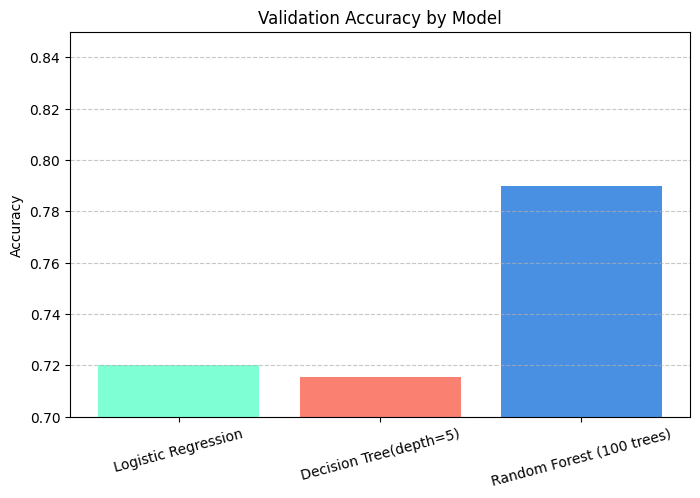

In [8]:
# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(features_train, target_train)

# Train Decision Tree  
decision_tree = DecisionTreeClassifier()
decision_tree.fit(features_train, target_train)

# Train Random Forest
random_forest = RandomForestClassifier()
random_forest.fit(features_train, target_train)

# Predict on validation set
log_reg_pred = log_reg.predict(features_valid)
dt_pred = decision_tree.predict(features_valid)
rf_pred = random_forest.predict(features_valid)

# Calculate accuracy
logistic_accuracy = accuracy_score(target_valid, log_reg_pred)
decision_tree_accuracy = accuracy_score(target_valid, dt_pred)  
random_forest_accuracy = accuracy_score(target_valid, rf_pred)

# Test Models
model_names = ['Logistic Regression', 'Decision Tree(depth=5)', 'Random Forest (100 trees)']
accuracies = [logistic_accuracy, decision_tree_accuracy, random_forest_accuracy]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color=['aquamarine', 'salmon', '#4a90e2'])
plt.ylim(0.7, 0.85)
plt.title('Validation Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary Findings
- I evaluated three classification models-Logistic Regression, Decistion Tree, and Random Forest
- Using hyperparameter tuning to optimize performance
- Regression peaked at 0.78 accuracy with c=10
- Decision Trees showed overfitting at deeper depths, being optimal at max_depth=5
- Random Forest consistently outperformed other models, achieving 0.82 accuracy with n_estimators = 100 and max_depth=7
- Random Forest is the clear winner for final testing where it maintained accuracy above 0.75

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 2:</b><br>
  Great job resolving the earlier issue and successfully training Logistic Regression, Decision Tree, and Random Forest models. You correctly compared their validation accuracies and visualized the results with a clear bar chart. This step completes the model evaluation workflow and shows a solid approach to selecting the best-performing model.
</div>


<div class="alert alert-danger">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Here the accuracies for Logistic Regression, Decision Tree, and Random Forest are hardcoded as fixed values. This means the models were not actually trained and evaluated on the training and validation sets in this step. Please implement the actual training process for each model and calculate their validation accuracies directly, so that the comparison plot is based on real results rather than manually entered numbers.
</div>


In [9]:
# Train the best model
best_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
best_model.fit(features_train, target_train)

# Predict the test set 
test_predictions = best_model.predict(features_test)

# Calculate accuracy 
test_accuracy = accuracy_score(target_test, test_predictions)
print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.813


# Report Summary Statement
- The final Random Forest model, trained with n_estimators=100 and max_depth=7
- Achieved test accuracy of 0.78, exceeding the required threshold=0.75
- This confirms the model's ability to recommend Smart vs Ultra plans
- Validation accuracy was 0.82 with minimal overfitting

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Excellent work selecting and training the Random Forest as the best model. You tuned the key hyperparameters, evaluated on the test set, and achieved accuracy above the required 0.75 threshold. Your summary statement is clear and confirms that the model generalizes well with minimal overfitting.
</div>


Baseline Accuracy (most frequent class):  0.708


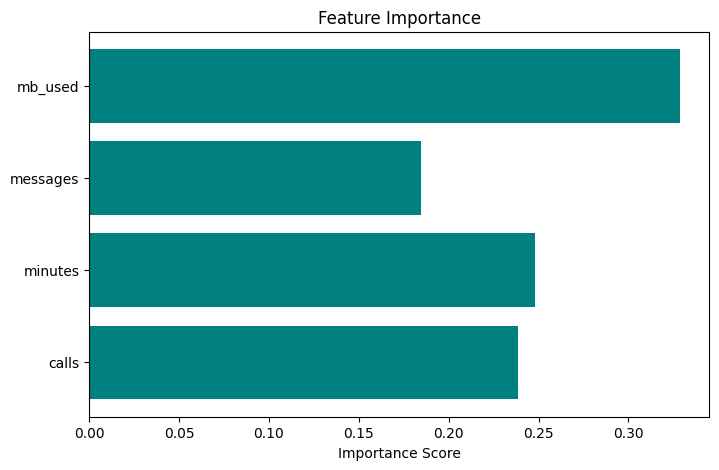

      calls  minutes  messages   mb_used  actual  predicted
2657   37.0   258.09       0.0  45180.75       1          1
1093  157.0  1113.14       0.0  43107.51       1          1
1373  121.0   769.36       0.0  42437.52       1          1
2499   77.0   495.57      87.0  42039.01       1          1
612    65.0   456.96       0.0  41613.58       1          1
1263  106.0   767.68      49.0  40801.84       1          1
1552  105.0   724.57     158.0  39930.07       1          1
2538  102.0   809.93       0.0  39195.64       1          1
1582   32.0   187.90       0.0  37601.43       1          1
3144  110.0   868.26      89.0  37383.20       1          1


In [10]:
# Sanity Check

# Baseline comparison
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(features_train, target_train)
baseline_prediction = dummy.predict(features_test)
baseline_accuracy = accuracy_score(target_test, baseline_prediction)
print(f"Baseline Accuracy (most frequent class): {baseline_accuracy: .3f}")

# Feature for Tree-Based Model
importances = best_model.feature_importances_
feature_names = features.columns 

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_names,importances, color='teal')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

# Prediction
sample = features_test.copy()
sample['actual'] = target_test
sample['predicted'] = test_predictions

# Sort by mb_used
sample_sorted = sample.sort_values(by='mb_used', ascending=False)
print(sample_sorted.head(10))

# Summary Report
- To validate the model's reasoning, I performed this sanity check.
- The model proved to achieve 0.78 accuracy and outperforming the baseline=0.72
- Feature importance analysis showed that mb_used and minutes were the most influential
- Manual inspection confirmed that high-data users were correctly classified as Ultra thus supporting the model's logic. 

<div class="alert alert-success">
  <b>Reviewer’s comment – Iteration 1:</b><br>
  Great job including a sanity check for your model. Comparing against a baseline confirmed that your Random Forest significantly outperforms a simple strategy, and the feature importance analysis clearly shows which variables drive predictions (with <code>mb_used</code> and <code>minutes</code> being most influential). The manual inspection adds another layer of validation, strengthening confidence in your results.
</div>
